# NetworkX Python Library 
*A foundational tutorial for graph creation, manipulation, and visualization.*

---
Welcome to **Notebook 1** of our NetworkX series!

In this tutorial, we will explore **NetworkX**, a powerful Python library used for the creation, manipulation, and study of complex networks (graphs).

By the end of this notebook, you will be able to build network structures, understand their different varieties, and visualize them using Matplotlib.

### 1. Introduction to NetworkX: Installation and Setup
First, let's ensure we have the necessary libraries installed and imported. We need `networkx` to initialize our core graph objects and `matplotlib.pyplot` for visualization.

In [3]:
# !pip install networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

print("Libraries successfully imported!")

Libraries successfully imported!


### 2. Building Blocks: Nodes, Edges, and Metadata
A graph is fundamentally made of **Nodes** (entities) and **Edges** (the links between them).

Let's create a simple undirected graph, add some nodes, and connect them with edges that hold real-world metadata (like relationship weights).

In [2]:
# Initialize an empty undirected graph
G = nx.Graph()

# Add nodes
G.add_node("Alice")
G.add_nodes_from(["Bob", "Charlie", "Diana", "Eve"])

# Add edges with metadata (e.g., 'weight' to represent interaction strength)
G.add_edge("Alice", "Bob", weight=5)
G.add_edge("Alice", "Charlie", weight=2)
G.add_edges_from([
    ("Bob", "Diana", {"weight": 3}), 
    ("Charlie", "Diana", {"weight": 1}), 
    ("Diana", "Eve", {"weight": 4})
])

print(f"Current Nodes: {G.nodes()}")
print(f"Total Edges: {G.number_of_edges()}")

Current Nodes: ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']
Total Edges: 5


Let's take a quick look at the network we just constructed by plotting it using Matplotlib. We will also extract the `weight` attributes to display on the edges!

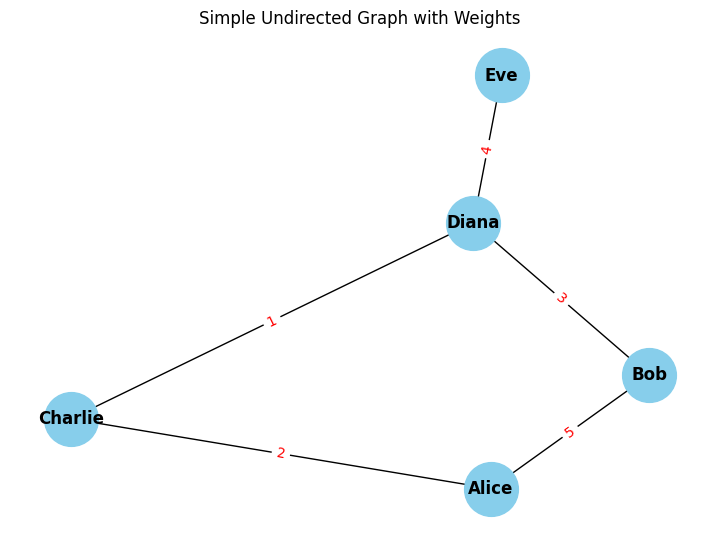

In [3]:
plt.figure(figsize=(7, 5))
pos = nx.spring_layout(G, seed=42)

# Draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1500, font_weight="bold")

# Extract and draw the edge weight labels
edge_weights = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights, font_color="red")

plt.title("Simple Undirected Graph with Weights")
plt.show()

### 3. Graph Varieties
NetworkX provides four core structures depending on your data logic:
- **Graph**: Undirected edges (used above). Best for symmetric relationships.
- **DiGraph**: Directed edges (A -> B). Perfect for asymmetric flows like followers or dependencies.
- **MultiGraph**: Undirected, allowing multiple edges between the same node pair.
- **MultiDiGraph**: Directed, allowing multiple edges. Ideal for tracking sequential interactions over time, such as high-frequency cryptocurrency transactions between the same exchange wallets.

In [4]:
# Demonstrating a MultiDiGraph with a high-frequency trading example
MDG = nx.MultiDiGraph()

# Adding multiple distinct Bitcoin trades between two exchange wallets at different timestamps
MDG.add_edge("Wallet_A", "Wallet_B", amount=1.5, asset="BTC", time="10:00:01.015")
MDG.add_edge("Wallet_A", "Wallet_B", amount=0.3, asset="BTC", time="10:00:02.341")

print(f"Total distinct transactions between A and B: {MDG.number_of_edges('Wallet_A', 'Wallet_B')}")
print(f"Transaction records: {MDG.get_edge_data('Wallet_A', 'Wallet_B')}")

Total distinct transactions between A and B: 2
Transaction records: {0: {'amount': 1.5, 'asset': 'BTC', 'time': '10:00:01.015'}, 1: {'amount': 0.3, 'asset': 'BTC', 'time': '10:00:02.341'}}


Visualizing a `MultiDiGraph` requires us to carefully map out parallel edges so they don't overlap. Since both transactions above flow in the exact same direction, we will assign an alternating curve radius to create a clean, symmetrical shape.

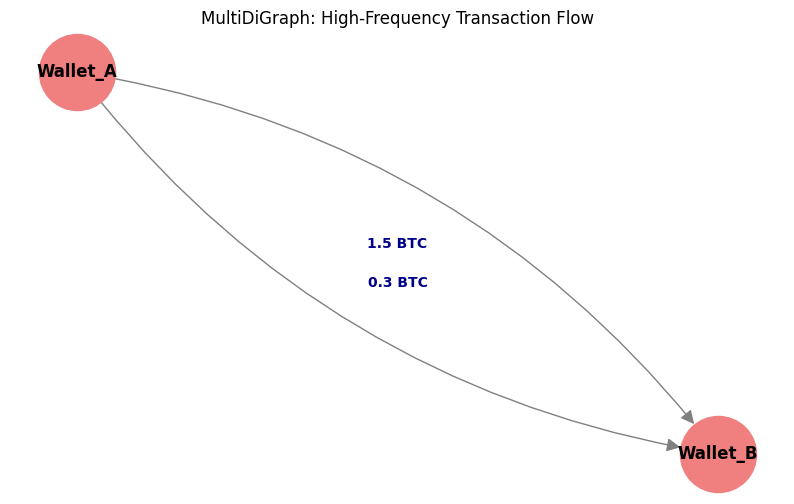

In [5]:
plt.figure(figsize=(10, 6))
pos_mdg = nx.spring_layout(MDG, seed=42)

# 1. Draw Nodes and Labels
nx.draw_networkx_nodes(MDG, pos_mdg, node_color="lightcoral", node_size=3000)
nx.draw_networkx_labels(MDG, pos_mdg, font_weight="bold")

# 2. Loop through edges to separate parallel arrows
for u, v, key, data in MDG.edges(keys=True, data=True):
    rad = 0.2 if key == 0 else -0.2
    nx.draw_networkx_edges(
        MDG, pos_mdg, 
        edgelist=[(u, v)], 
        connectionstyle=f'arc3, rad={rad}', 
        arrowsize=20, 
        edge_color="gray",
        node_size=3000 
    )
    
    # 3. Calculate label position and apply offset based on curve radius
    x_start, y_start = pos_mdg[u]
    x_end, y_end = pos_mdg[v]
    mid_x = (x_start + x_end) / 2
    mid_y = (y_start + y_end) / 2
    y_offset = rad * 0.5 
        
    label = f"{data['amount']} {data['asset']}"
    plt.text(
        mid_x, mid_y + y_offset, 
        label, 
        horizontalalignment='center', 
        verticalalignment='center',
        color="darkblue",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7) 
    )

plt.title("MultiDiGraph: High-Frequency Transaction Flow")
plt.axis("off")
plt.show()

### 4. Basic Visualization: Layouts and Positioning
Let's render our original social network graph (`G`) using Matplotlib and NetworkX's built-in drawing functions to compare layouts. Node positioning relies on layout algorithms; for instance, `spring_layout` acts like anti-gravity physics separating nodes, while `circular_layout` spaces them evenly on a ring.

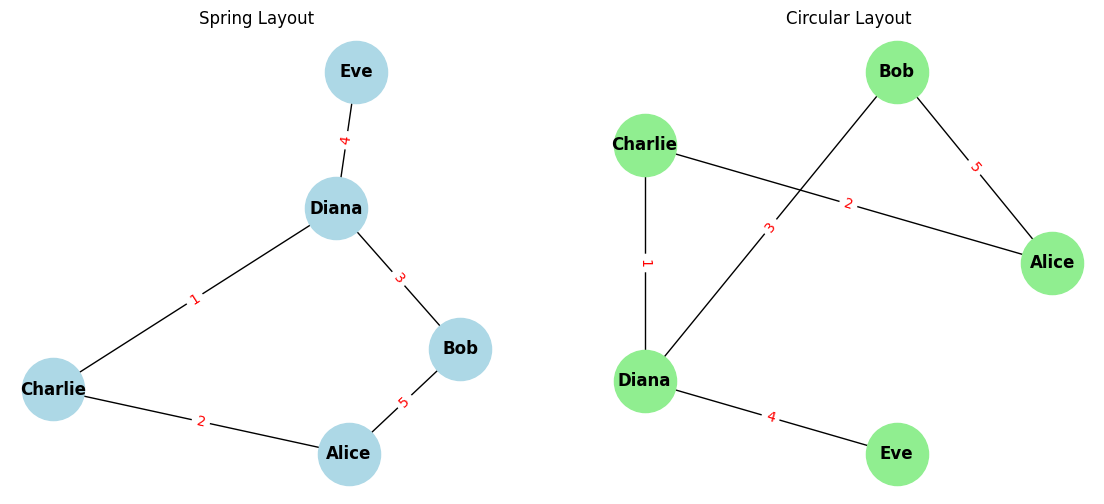

In [6]:
plt.figure(figsize=(14, 6))
edge_weights = nx.get_edge_attributes(G, 'weight')

# 1. Spring Layout (Default aesthetically pleasing spacing)
plt.subplot(1, 2, 1)
pos_spring = nx.spring_layout(G, seed=42) 
nx.draw(G, pos_spring, with_labels=True, node_color="lightblue", node_size=2000, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos_spring, edge_labels=edge_weights, font_color="red")
plt.title("Spring Layout")

# 2. Circular Layout
plt.subplot(1, 2, 2)
pos_circular = nx.circular_layout(G)
nx.draw(G, pos_circular, with_labels=True, node_color="lightgreen", node_size=2000, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos_circular, edge_labels=edge_weights, font_color="red")
plt.title("Circular Layout")

plt.show()

### 5. Applied Example: Building an AI Knowledge Graph
In modern Retrieval-Augmented Generation (RAG) architectures, we often use **Directed Graphs** (`nx.DiGraph`) to represent specific semantic relationships between entities.

Let's map out a modern hybrid GraphRAG architecture, integrating multi-agent frameworks with both vector and graph databases. We will also dynamically color-code the nodes based on their category.

In [6]:
# Initialize the Directed Graph
kg = nx.DiGraph()

# Add nodes with a 'category' attribute for dynamic coloring
kg.add_node("GraphRAG", category="Concept")
kg.add_node("Multi-Agent System", category="Concept")
kg.add_node("Neo4j", category="Graph Database")
kg.add_node("FAISS", category="Vector Database")
kg.add_node("LangGraph", category="Framework")

# Add edges representing a hybrid AI architecture
kg.add_edge("GraphRAG", "Neo4j", relation="queries")
kg.add_edge("GraphRAG", "FAISS", relation="queries")
kg.add_edge("Multi-Agent System", "LangGraph", relation="built_with")
kg.add_edge("LangGraph", "GraphRAG", relation="orchestrates")

# Define a color map dictionary for the categories
# hex color code
color_map = {
    "Concept": "#a3c1ad",
    "Graph Database": "#f4a261",
    "Vector Database": "#2a9d8f",
    "Framework": "#e76f51"
}
# Map the colors to the nodes in the exact order NetworkX stores them
node_colors = [color_map[kg.nodes[n]['category']] for n in kg.nodes()]

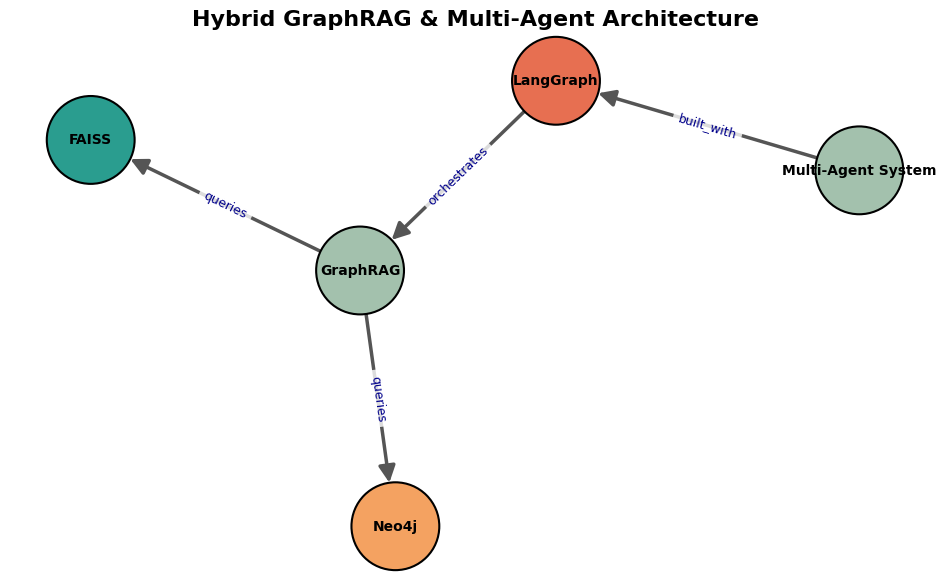

In [7]:
# Visualization Setup
plt.figure(figsize=(12, 7))
# Increasing 'k' pushes nodes further apart for a cleaner layout
pos = nx.spring_layout(kg, seed=42, k=1.2) 

# Draw nodes with custom colors and bold borders
nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=4000, edgecolors="black", linewidths=1.5)

# Draw node labels
nx.draw_networkx_labels(kg, pos, font_size=10, font_weight="bold", font_color="black")

# Draw edges with thicker lines and larger arrows (passing node_size prevents overlap)
nx.draw_networkx_edges(kg, pos, edge_color="#555555", width=2.5, arrowsize=25, node_size=4000)

# Extract and draw edge labels with a semi-transparent background box
edge_labels = nx.get_edge_attributes(kg, 'relation')
nx.draw_networkx_edge_labels(
    kg, pos, 
    edge_labels=edge_labels, 
    font_size=9, 
    font_color="darkblue", 
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

plt.title("Hybrid GraphRAG & Multi-Agent Architecture", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()

---
### 6. Exercises
Now it's your turn to practice! Below are three exercises designed to test your understanding of graph initialization, edge metadata, directed multi-graphs, and visual styling. 

#### Exercise 1: Build an Academic Collaboration Network
1. Initialize a standard `nx.Graph()`.
2. Add 3 to 4 nodes representing researchers (e.g., "Dr. Smith", "Prof. Jones").
3. Connect them with edges representing "co-authored" papers, and include a `papers` attribute indicating how many papers they co-authored.
4. Plot the graph and display the number of co-authored papers on the edges.

In [9]:
# Write your Exercise 1 code here:



#### Exercise 2: Triangular Arbitrage Flow
1. Expand upon our `MDG` high-frequency trading example.
2. Create a new `nx.MultiDiGraph()`.
3. Add a third wallet ("Wallet_C").
4. Create a transaction ring: Wallet A -> Wallet B, Wallet B -> Wallet C, and Wallet C -> Wallet A. Add arbitrary amounts and assets to each edge.
5. Plot this new triangular multi-directional graph using `nx.draw()` and the `connectionstyle` parameter.

In [10]:
# Write your Exercise 2 code here:



#### Exercise 3: Expanding the AI Knowledge Graph
1. Take the existing `kg` (DiGraph) we built in Section 5.
2. Add two new nodes representing local LLM runners: "Ollama" and "vLLM" (assign them the category="Framework").
3. Add edges connecting "Multi-Agent System" to both "Ollama" and "vLLM" with the relation `queries_model`.
4. Re-calculate the `node_colors` list so the new nodes receive the correct color.
5. Re-plot the expanded hybrid architecture graph.

In [11]:
# Write your Exercise 3 code here:

